# GSM8K - Llama 3.2-3B (Base)

**Tinker RL Project — PES University MTech Capstone (Group 6)**

| Field | Value |
|-------|-------|
| **Model** | `meta-llama/Llama-3.2-3B` |
| **Parameters** | 3B |
| **Benchmark** | GSM8K (Grade School Math) |
| **Method** | GRPO (Group Relative Policy Optimization) + LoRA rank 32 |
| **Training API** | Tinker (Thinking Machines) — cloud GPU training |
| **Environment** | Atropos (NousResearch) — RL rollout framework |
| **Status** | Complete (Negative Result) |
| **Tinker URI** | `tinker://03d1371d-.../sampler_weights/step_50` |


## Experiment Description

This experiment trains Llama 3.2-3B (base, not instruct) on GSM8K — testing the lower end of the scaling ladder.

**Key findings (NEGATIVE RESULT):**
- Started near 0% and never exceeded ~3% accuracy across 50 steps
- This is an important scaling insight: 3B base parameters may be **below the threshold** for learning math reasoning via GRPO alone
- Most batches had zero reward (model couldn't solve any problems), causing zero-advantage skipping
- The model likely lacks sufficient pre-trained math knowledge to bootstrap RL learning
- Contrast with Qwen3-8B (base) which went 7% → 100% — the jump from 3B to 8B is critical



## Training Configuration

In [1]:
# Training configuration (gsm8k_llama_3b.yaml)
config_yaml = """
# GSM8K GRPO - Llama 3.2-3B (Scaling experiment)
# Experiment: GRPO scaling ladder - 3B parameter point
# Uses unsloth mirror for tokenizer (meta-llama is gated)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "unsloth/Llama-3.2-3B"
  use_wandb: false
  rollout_server_url: "http://localhost:8004"
  wandb_name: "gsm8k-llama3.2-3b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "unsloth/Llama-3.2-3B"
    base_url: "http://localhost:8005/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00005
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_llama3b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-llama3.2-3b"
  tinker_model_name: "meta-llama/Llama-3.2-3B"

slurm: false
testing: false"""
print(config_yaml)


# GSM8K GRPO - Llama 3.2-3B (Scaling experiment)
# Experiment: GRPO scaling ladder - 3B parameter point
# Uses unsloth mirror for tokenizer (meta-llama is gated)

env:
  group_size: 16
  batch_size: 128
  max_batches_offpolicy: 3
  tokenizer_name: "unsloth/Llama-3.2-3B"
  use_wandb: false
  rollout_server_url: "http://localhost:8004"
  wandb_name: "gsm8k-llama3.2-3b-env"
  ensure_scores_are_not_same: false
  max_token_length: 512
  max_num_workers: 24
  total_steps: 50
  steps_per_eval: 25

openai:
  - model_name: "unsloth/Llama-3.2-3B"
    base_url: "http://localhost:8005/v1"
    api_key: "x"
    weight: 1.0
    num_requests_for_eval: 256

tinker:
  lora_rank: 32
  learning_rate: 0.00005
  max_token_trainer_length: 2048
  checkpoint_dir: "./checkpoints/gsm8k_llama3b/"
  save_checkpoint_interval: 10
  wandb_project: "tinker-rl-scaling"
  wandb_group: "gsm8k-scaling-ladder"
  wandb_run_name: "gsm8k-llama3.2-3b"
  tinker_model_name: "meta-llama/Llama-3.2-3B"

slurm: false
testing: false

## Training Results

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)

steps = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
rewards = [0.0078, 0.0156, 0.0, 0.0, 0.0156, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0078, 0.0, 0.0, 0.0, 0.0078, 0.0, 0.0, 0.0, 0.0078, 0.0078, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0078, 0.0078, 0.0, 0.0078, 0.0078, 0.0234, 0.0, 0.0, 0.0, 0.0078, 0.0234, 0.0312, 0.0234]
losses = [-108.02021789550781, 128.00148010253906, 0.0, 0.0, 69.47098541259766, 0.0, 0.0, -74.22322082519531, 290.18193912506104, 0.0, 0.0, 104.5279312133789, -105.34099578857422, 0.0, 0.0, -99.18541717529297, 0.0, 0.0, 0.0, -176.99666595458984, 0.0, 0.0, 0.0, 237.11676025390625, -207.67515563964844, 0.0, 0.0, 0.0, 0.0, 0.0, -137.29087829589844, 236.98238945007324, 0.0, 0.0, 0.0, 0.0, 0.0, 273.118145942688, 262.73577880859375, 0.0, 111.51870727539062, -84.42706298828125, 674.4336624145508, 0.0, 0.0, 0.0, -104.71083068847656, 174.53131866455078, -377.9182586669922, -346.256103515625]

print(f"Total steps completed: {len(steps)}")
print(f"Initial reward: {rewards[0]:.4f}" if rewards else "No data")
print(f"Final reward: {rewards[-1]:.4f}" if rewards else "No data")
print(f"Peak reward: {max(rewards):.4f}" if rewards else "No data")
print(f"Mean reward (last 10): {sum(rewards[-10:])/len(rewards[-10:]):.4f}" if len(rewards) >= 10 else "")


Total steps completed: 50
Initial reward: 0.0078
Final reward: 0.0234
Peak reward: 0.0312
Mean reward (last 10): 0.0125


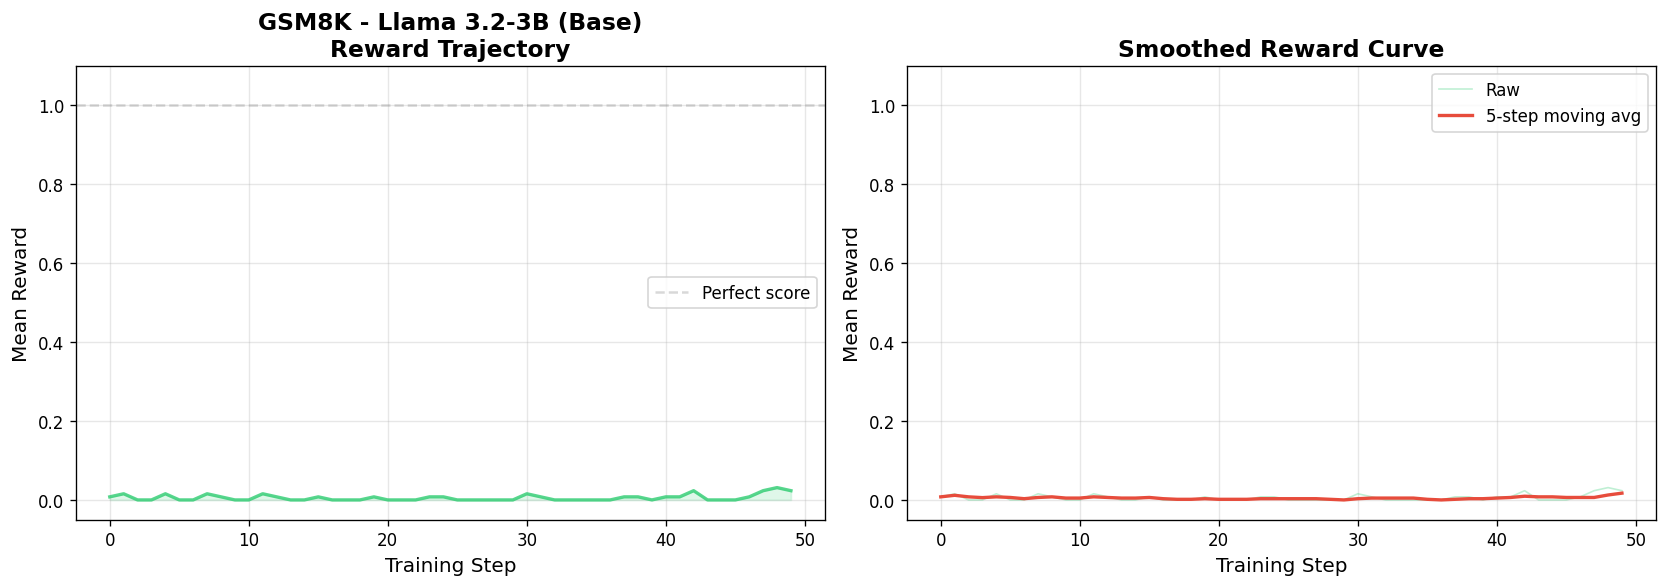

In [3]:
# Reward trajectory
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
ax1.plot(steps, rewards, color='#2ecc71', linewidth=2, alpha=0.8)
ax1.fill_between(steps, rewards, alpha=0.15, color='#2ecc71')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.set_title('GSM8K - Llama 3.2-3B (Base)\nReward Trajectory', fontsize=14, fontweight='bold')
ax1.set_ylim(-0.05, 1.1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Perfect score')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Moving average
window = min(5, len(rewards))
if window > 1:
    moving_avg = [sum(rewards[max(0,i-window+1):i+1])/len(rewards[max(0,i-window+1):i+1]) for i in range(len(rewards))]
    ax2.plot(steps, rewards, color='#2ecc71', alpha=0.3, linewidth=1, label='Raw')
    ax2.plot(steps, moving_avg, color='#e74c3c', linewidth=2, label=f'{window}-step moving avg')
    ax2.set_xlabel('Training Step', fontsize=12)
    ax2.set_ylabel('Mean Reward', fontsize=12)
    ax2.set_title('Smoothed Reward Curve', fontsize=14, fontweight='bold')
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()


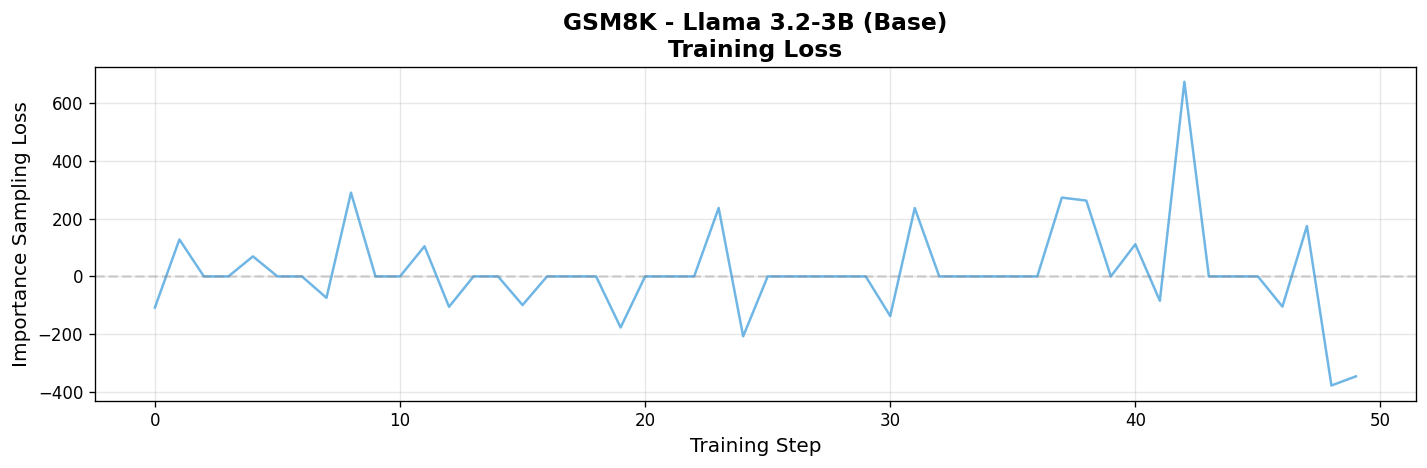

In [4]:
# Loss trajectory
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(steps, losses, color='#3498db', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Importance Sampling Loss', fontsize=12)
ax.set_title('GSM8K - Llama 3.2-3B (Base)\nTraining Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Step-by-Step Data

In [5]:
import pandas as pd
df = pd.DataFrame({
    'Step': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
    'Reward': [0.0078, 0.0156, 0.0, 0.0, 0.0156, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0078, 0.0, 0.0, 0.0, 0.0078, 0.0, 0.0, 0.0, 0.0078, 0.0078, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0156, 0.0078, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0078, 0.0078, 0.0, 0.0078, 0.0078, 0.0234, 0.0, 0.0, 0.0, 0.0078, 0.0234, 0.0312, 0.0234],
    'Loss': [-108.02021789550781, 128.00148010253906, 0.0, 0.0, 69.47098541259766, 0.0, 0.0, -74.22322082519531, 290.18193912506104, 0.0, 0.0, 104.5279312133789, -105.34099578857422, 0.0, 0.0, -99.18541717529297, 0.0, 0.0, 0.0, -176.99666595458984, 0.0, 0.0, 0.0, 237.11676025390625, -207.67515563964844, 0.0, 0.0, 0.0, 0.0, 0.0, -137.29087829589844, 236.98238945007324, 0.0, 0.0, 0.0, 0.0, 0.0, 273.118145942688, 262.73577880859375, 0.0, 111.51870727539062, -84.42706298828125, 674.4336624145508, 0.0, 0.0, 0.0, -104.71083068847656, 174.53131866455078, -377.9182586669922, -346.256103515625],
})
df['Reward_pct'] = (df['Reward'] * 100).round(2).astype(str) + '%'
print(df[['Step', 'Reward_pct', 'Loss']].to_string(index=False))


 Step Reward_pct        Loss
    0      0.78% -108.020218
    1      1.56%  128.001480
    2       0.0%    0.000000
    3       0.0%    0.000000
    4      1.56%   69.470985
    5       0.0%    0.000000
    6       0.0%    0.000000
    7      1.56%  -74.223221
    8      0.78%  290.181939
    9       0.0%    0.000000
   10       0.0%    0.000000
   11      1.56%  104.527931
   12      0.78% -105.340996
   13       0.0%    0.000000
   14       0.0%    0.000000
   15      0.78%  -99.185417
   16       0.0%    0.000000
   17       0.0%    0.000000
   18       0.0%    0.000000
   19      0.78% -176.996666
   20       0.0%    0.000000
   21       0.0%    0.000000
   22       0.0%    0.000000
   23      0.78%  237.116760
   24      0.78% -207.675156
   25       0.0%    0.000000
   26       0.0%    0.000000
   27       0.0%    0.000000
   28       0.0%    0.000000
   29       0.0%    0.000000
   30      1.56% -137.290878
   31      0.78%  236.982389
   32       0.0%    0.000000
   33       0.

## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    GRPO Training Pipeline                       │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌─────────────┐    ┌──────────────┐    ┌───────────────────┐  │
│  │  Atropos     │───▶│  Environment │───▶│  Tinker Trainer   │  │
│  │  (run-api)   │    │  (GSM8K/MATH)│    │  (GRPO + LoRA)   │  │
│  │  Coordinator │◀───│  Scoring     │◀───│  Cloud GPUs      │  │
│  └─────────────┘    └──────────────┘    └───────────────────┘  │
│        │                    │                      │            │
│        │              Rollouts with           LoRA weights      │
│        │              binary rewards         updated via        │
│        │              (0 or 1)            importance sampling    │
│        │                    │                      │            │
│        └────────────────────┴──────────────────────┘            │
│                      Data flow loop                             │
└─────────────────────────────────────────────────────────────────┘
```
